In [ ]:
from chipanalysis.utils.file_reader import load_czi_2d,_squeeze_to_2d,stretch_contrast,get_frame
from pathlib import Path
from aicspylibczi import CziFile
import matplotlib.pyplot as plt
import numpy as np
%matplotlib widget


In [2]:
root_path = "/home/bisot/shares/van_gestel_server/ZeissData/slugs"
fig_path = "/home/bisot/shares/van_gestel_server/ZeissData/figs"

czi_name = "slugcrossing2.czi"

czi_path = Path(root_path,czi_name)
czi = CziFile(czi_path)

dims = czi.dims
sizes = czi.size

dim_sizes = dict(zip(dims, sizes))
dim_sizes["T"]


151

In [4]:
channel = 1
time = 100
img, img_disp = get_frame(czi,time,channel)

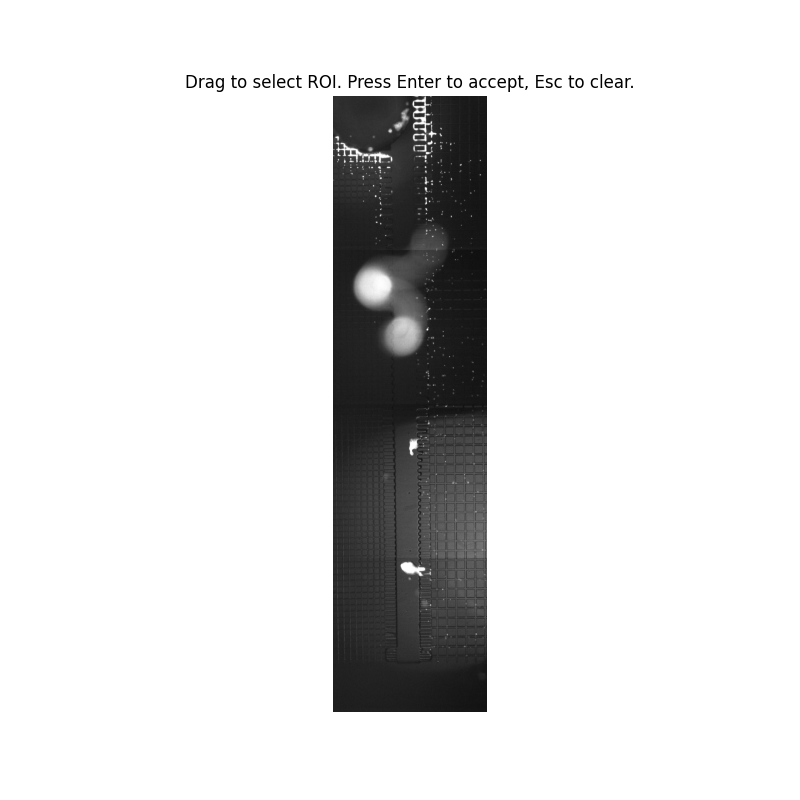

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import RectangleSelector

# img_disp should be a 2D array you display (e.g. contrast-stretched)
# If you already have `img` from the CZI loader, do:
img_disp = stretch_contrast(img, 1, 99)

roi = {"x0": None, "y0": None, "x1": None, "y1": None}

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(img_disp, cmap="gray", vmin=0, vmax=1)
ax.set_title("Drag to select ROI. Press Enter to accept, Esc to clear.")
ax.set_axis_off()

def onselect(eclick, erelease):
    x0, y0 = float(eclick.xdata), float(eclick.ydata)
    x1, y1 = float(erelease.xdata), float(erelease.ydata)

    x0, x1 = sorted([x0, x1])
    y0, y1 = sorted([y0, y1])

    roi.update({"x0": x0, "y0": y0, "x1": x1, "y1": y1})
    print("ROI:", roi)

rect_selector = RectangleSelector(
    ax,
    onselect,
    useblit=True,
    button=[1],          # left mouse button
    interactive=True,    # allow resizing/moving after draw
    minspanx=5,
    minspany=5,
    spancoords="pixels",
)

def on_key(event):
    if event.key == "enter":
        print("Accepted ROI:", roi)
    elif event.key == "escape":
        rect_selector.set_visible(False)
        rect_selector.set_visible(True)  # quick clear/redraw
        roi.update({"x0": None, "y0": None, "x1": None, "y1": None})
        fig.canvas.draw_idle()
        print("Cleared ROI")

fig.canvas.mpl_connect("key_press_event", on_key)
plt.show()


In [6]:
roi_saved = roi

In [7]:
roi_saved

{'x0': 331.1246306184048,
 'y0': 4228.577262581168,
 'x1': 1957.202552696327,
 'y1': 7803.018821022726}

In [8]:
roi_saved = {'x0': 50.77272727272748,
 'y0': 2449.603896103896,
 'x1': 1995.4740259740256,
 'y1': 6009.396103896104}
roi_saved = {'x0': 331.1246306184048,
 'y0': 4228.577262581168,
 'x1': 1957.202552696327,
 'y1': 7803.018821022726}

In [9]:
channel = 1
time = 110
img, img_disp = get_frame(czi,time,channel,roi=roi_saved,gamma=1)

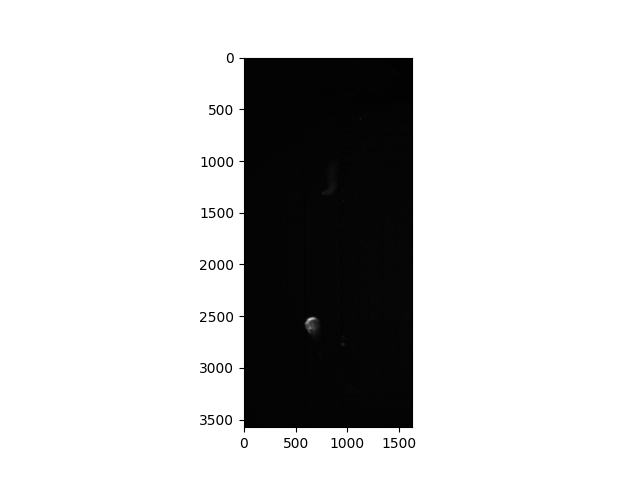

In [10]:
fig,ax = plt.subplots()
ax.imshow(img,cmap="gray")

In [11]:
import numpy as np
import cv2

def log_image(gray, sigma=1.5):
    gray = gray.astype(np.float32)

    # let OpenCV pick kernel size from sigma
    blurred = cv2.GaussianBlur(gray, ksize=(0, 0), sigmaX=sigma, sigmaY=sigma)

    # Laplacian (second derivative)
    log = cv2.Laplacian(blurred, ddepth=cv2.CV_32F, ksize=3)
    return log

def hessian_det_blob_cv2(gray, sigma=1.6):
    I = gray.astype(np.float32)

    # Smooth at scale sigma
    S = cv2.GaussianBlur(I, (0, 0), sigmaX=sigma, sigmaY=sigma)

    # Second derivatives (Sobel 2nd order)
    Ixx = cv2.Sobel(S, cv2.CV_32F, dx=2, dy=0, ksize=3)
    Iyy = cv2.Sobel(S, cv2.CV_32F, dx=0, dy=2, ksize=3)
    Ixy = cv2.Sobel(S, cv2.CV_32F, dx=1, dy=1, ksize=3)

    # Scale-normalization (important for multi-scale blob detection)
    s2 = sigma * sigma
    Ixx *= s2; Iyy *= s2; Ixy *= s2

    detH = Ixx * Iyy - Ixy * Ixy            # = λ1 * λ2
    trace = Ixx + Iyy                       # = λ1 + λ2

    # If you want bright blobs on dark background:
    detH = np.where(trace < 0, detH, 0.0)

    return detH, trace, (Ixx, Iyy, Ixy)

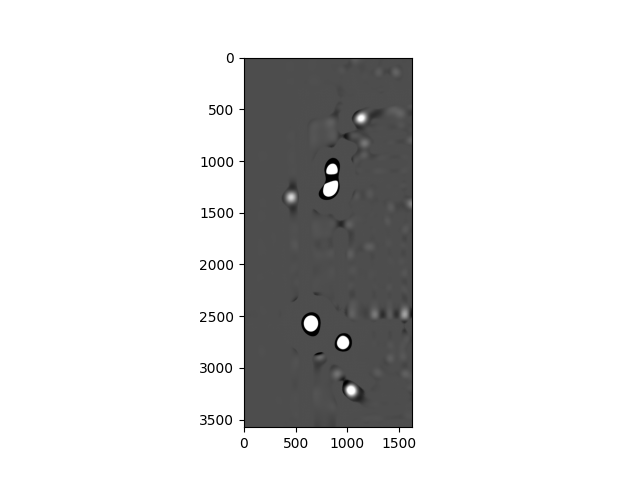

In [34]:
fig,ax = plt.subplots()
ax.imshow(stretch_contrast(hessian_det_blob_cv2(img,60)[0],1,99),cmap="gray")

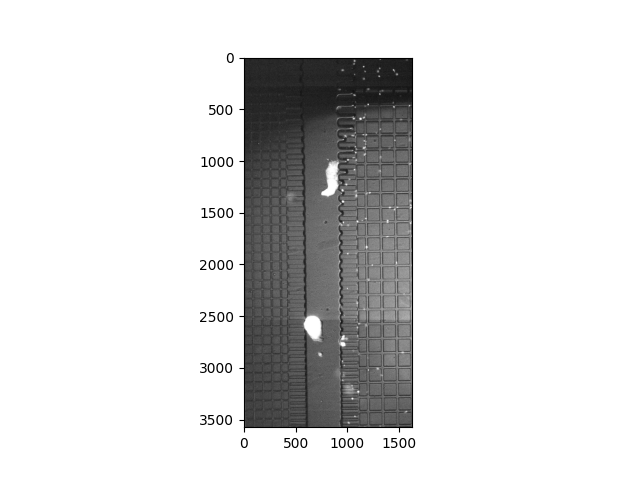

In [35]:
fig,ax = plt.subplots()
ax.imshow(stretch_contrast(img,1,99),cmap="gray")

In [ ]:
fig,ax = plt.subplots()
ax.imshow(hessian_det_blob_cv2(img,60)[0],cmap="gray")

In [13]:
import pandas as pd
import numpy as np




def compute_profiles_over_time_wide(
    czi,
    times,
    channel,
    roi=None,
    metrics=None
):
    """
    Returns DataFrame with columns:
      t, x, <metric1>, <metric2>, ...
    """
    if metrics is None:
        metrics = {"mean": profile_mean}

    frames = []

    for t in times:
        img, _ = get_frame(czi, t, channel, roi=roi, gamma=1)

        x = np.arange(img.shape[1])
        row = {"t": t, "x": x}

        for name, fn in metrics.items():
            y = fn(img)
            if y.shape[0] != x.shape[0]:
                raise ValueError(f"Metric '{name}' returned shape {y.shape}, expected (X,)")
            row[name] = y

        frames.append(pd.DataFrame(row))

    return pd.concat(frames, ignore_index=True)

In [14]:

def profile_mean(img):      return np.mean(img, axis=0)
def profile_blob(img):      return np.mean(hessian_det_blob_cv2(img,40)[0], axis=0)
def profile_blob20(img):      return np.mean(hessian_det_blob_cv2(img,20)[0], axis=0)
def profile_blob60(img):      return np.mean(hessian_det_blob_cv2(img,60)[0], axis=0)




times = list(range(0, dim_sizes["T"], 1))


metrics = {
    "mean": profile_mean,
    "profile_blob": profile_blob,
    "profile_blob20": profile_blob20,
    "profile_blob60": profile_blob60,


}

df = compute_profiles_over_time_wide(czi, times, channel, roi=roi_saved, metrics=metrics)
df.head()


,t,x,mean,profile_blob,profile_blob20,profile_blob60
0,0,0,111.460266,0.382824,2.630683,-0.005525
1,0,1,111.583656,0.387486,2.644613,0.003990
2,0,2,111.693344,0.378436,2.615562,0.015829
3,0,3,111.625633,0.391897,2.550744,0.017174
4,0,4,112.416618,0.361142,2.487058,0.015178


In [15]:
from chipanalysis.utils.file_reader import *
pixel_size = get_pixel_sizes_um(czi)
times = get_timestamps_by_T(czi, C=0, Z=0)


.//Scaling//Distance[@Id='X']//Value
.//Scaling//Distance[@Id='Y']//Value


In [16]:
times_df = pd.DataFrame(times, columns=["t", "timestr"])
df = df.merge(times_df, on="t", how="left")

df["datetime"] = pd.to_datetime(df["timestr"], utc=True)
t0 = df.loc[df["t"] == 0, "datetime"].iloc[0]

df["timedelta_from_0"] = df["datetime"] - t0



In [17]:
df["timedelta_hours"] = df["timedelta_from_0"].dt.total_seconds()/3600

In [18]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np

mcherry = LinearSegmentedColormap.from_list(
    "mcherry",
    [
        (0.00, "#000000"),  # black
        (0.25, "#2a001f"),  # very dark purple
        (0.50, "#5c005c"),  # purple
        (0.75, "#a100a1"),  # strong magenta
        (1.00, "#ff33ff"),  # bright magenta
    ]
)

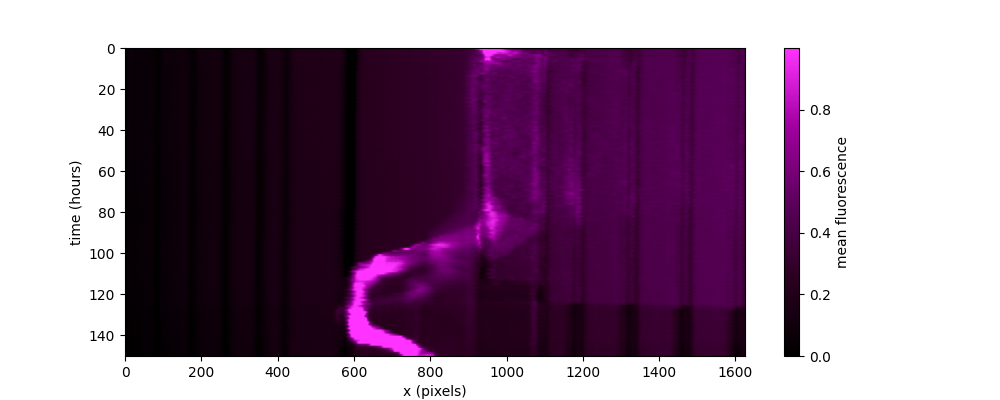

In [ ]:
y = df['t'].values
x = df['x'].values
metric = "mean"
pivot = df.pivot(index="t", columns="x", values=metric)

plt.figure(figsize=(10,4))
plt.imshow(
    stretch_contrast(pivot.values, 1, 99),
    aspect="auto",
    origin="lower",
    cmap=mcherry,
    extent=[x.min(), x.max(), y.min(), y.max()],
)
plt.colorbar(label="mean fluorescence")
plt.xlabel("x (pixels)")
plt.ylabel("time (hours)")

plt.gca().invert_yaxis()   # 👈 time 0 at the top

plt.savefig(Path(fig_path,"slug_trace.png"),bbox_inches = 'tight')

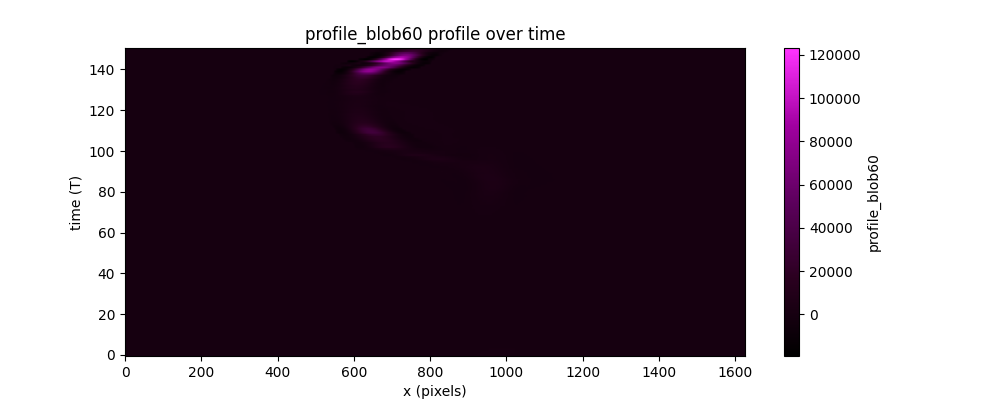

In [21]:
metric = "profile_blob60"
pivot = df.pivot(index="t", columns="x", values=metric)

plt.figure(figsize=(10,4))
plt.imshow(pivot.values, aspect="auto", origin="lower",cmap = mcherry)
plt.colorbar(label=metric)
plt.xlabel("x (pixels)")
plt.ylabel("time (T)")
plt.title(f"{metric} profile over time")
plt.show()


In [29]:
metric = "profile_blob60"   # or "std", "p90", etc.

df_time = (
    df.groupby("timedelta_hours", as_index=False)[metric]
      .mean()
)


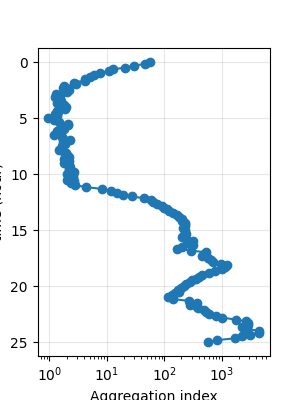

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(3,4))
plt.plot(df_time[f"{metric}"],df_time["timedelta_hours"], marker="o")
plt.xlabel("Aggregation index")
plt.ylabel(f"time (hour)")
plt.grid(True, alpha=0.3)
plt.gca().invert_yaxis()   # 👈 time 0 at the top
plt.xscale("log")
plt.savefig(Path(fig_path,"aggreg_index.png"),bbox_inches = 'tight')
